# **1. Perkenalan Dataset**

## Dataset: Heart Disease Cleveland (UCI Machine Learning Repository)

Dataset **Heart Disease Cleveland** berasal dari **UCI Machine Learning Repository**, salah satu repositori dataset publik yang paling terpercaya dan banyak digunakan dalam penelitian machine learning.

### Latar Belakang
Penyakit jantung (cardiovascular disease) merupakan penyebab kematian nomor satu secara global. Deteksi dini menggunakan data klinis pasien dapat membantu tenaga medis mengambil keputusan yang lebih cepat dan akurat. Dataset ini merekam berbagai parameter klinis dari 303 pasien di Cleveland Clinic Foundation untuk memprediksi ada tidaknya penyakit jantung.

### Informasi Dataset
| Keterangan | Detail |
|---|---|
| Sumber | UCI Machine Learning Repository |
| Jumlah Sampel | 303 baris |
| Jumlah Fitur | 13 fitur input + 1 target |
| Tipe Task | Klasifikasi Biner |
| Target | `target` (0 = tidak ada penyakit jantung, 1 = ada penyakit jantung) |

### Deskripsi Fitur
| Fitur | Tipe | Deskripsi |
|---|---|---|
| `age` | Numerik | Usia pasien (tahun) |
| `sex` | Kategorikal | Jenis kelamin (1=laki-laki, 0=perempuan) |
| `cp` | Kategorikal | Tipe nyeri dada (1=typical angina, 2=atypical angina, 3=non-anginal pain, 4=asymptomatic) |
| `trestbps` | Numerik | Tekanan darah istirahat (mmHg) |
| `chol` | Numerik | Kolesterol serum (mg/dl) |
| `fbs` | Kategorikal | Gula darah puasa > 120 mg/dl (1=ya, 0=tidak) |
| `restecg` | Kategorikal | Hasil elektrokardiogram istirahat (0, 1, 2) |
| `thalach` | Numerik | Denyut jantung maksimum yang dicapai |
| `exang` | Kategorikal | Angina akibat olahraga (1=ya, 0=tidak) |
| `oldpeak` | Numerik | Depresi segmen ST akibat olahraga relatif terhadap istirahat |
| `slope` | Kategorikal | Kemiringan segmen ST puncak olahraga (1, 2, 3) |
| `ca` | Numerik | Jumlah pembuluh darah utama yang terdeteksi fluoroskopi (0–3) |
| `thal` | Kategorikal | Thalassemia (3=normal, 6=fixed defect, 7=reversible defect) |
| `target` | Biner | Label kelas: 0 = tidak ada penyakit, 1 = ada penyakit |

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# Library dasar
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modeling
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

# Utilitas
import pickle
import os

print('Semua library berhasil diimpor!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Semua library berhasil diimpor!
NumPy  : 2.4.6
Pandas : 2.3.3


# **3. Memuat Dataset**

Dataset Heart Disease Cleveland dimuat dari file CSV. Kita periksa beberapa baris awal untuk memahami struktur dan format datanya.

In [2]:
# Muat dataset
df = pd.read_csv('../heart_disease_raw/heart_disease.csv')

print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Nama kolom     : {list(df.columns)}')
print()
df.head(10)

Jumlah baris   : 303
Jumlah kolom   : 14
Nama kolom     : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,45,0,2,142,126,0,1,110,1,1.2,2,2,3,1
1,63,1,4,107,259,0,1,170,0,1.2,1,1,3,0
2,57,0,1,150,279,0,0,127,0,0.2,1,2,7,1
3,41,1,2,120,233,0,0,152,0,0.6,1,2,3,1
4,49,1,2,115,297,0,0,109,0,1.4,2,2,3,1
5,69,0,2,120,240,0,2,159,1,0.4,1,0,3,0
6,33,1,4,131,286,0,0,194,0,0.1,2,2,7,1
7,51,0,4,111,364,0,0,119,1,0.0,1,0,6,0
8,66,0,2,134,242,1,0,162,0,1.1,1,0,3,0
9,47,1,1,108,146,1,0,156,0,0.0,3,2,3,0


In [3]:
# Informasi tipe data dan nilai non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Statistik deskriptif
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.125413,0.683168,2.597360,130.105611,247.953795,0.141914,0.514851,152.234323,0.323432,1.053135,1.590759,0.673267,4.818482,0.429043
std,9.164290,0.466011,1.117112,16.348504,47.559630,0.349539,0.580258,21.625528,0.468560,0.966414,0.617767,0.939659,1.931798,0.495758
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,79.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,2.000000,119.000000,214.000000,0.000000,0.000000,136.500000,0.000000,0.400000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,2.000000,131.000000,250.000000,0.000000,0.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,141.000000,278.000000,0.000000,1.000000,167.500000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,180.000000,379.000000,1.000000,2.000000,202.000000,1.000000,5.200000,3.000000,3.000000,7.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset: distribusi data, korelasi antar fitur, dan hubungan fitur dengan target.

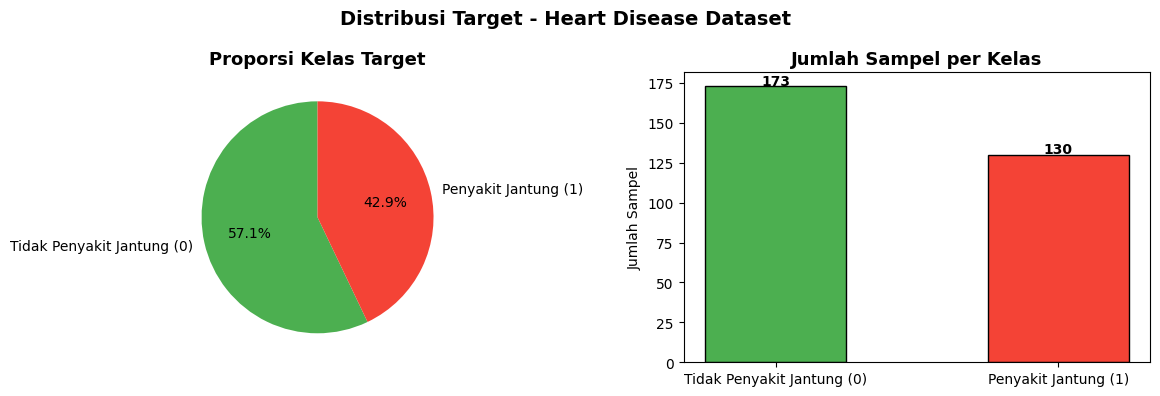

Distribusi kelas:
target
0    173
1    130

Rasio kelas: 1.33:1 (tidak sakit : sakit)


In [5]:
# --- 4.1 Distribusi Target ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['target'].value_counts()
labels = ['Tidak Penyakit Jantung (0)', 'Penyakit Jantung (1)']
colors = ['#4CAF50', '#F44336']

axes[0].pie(target_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

axes[1].bar(labels, target_counts, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Distribusi Target - Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Distribusi kelas:\n{target_counts.to_string()}')
print(f'\nRasio kelas: {target_counts[0]/target_counts[1]:.2f}:1 (tidak sakit : sakit)')

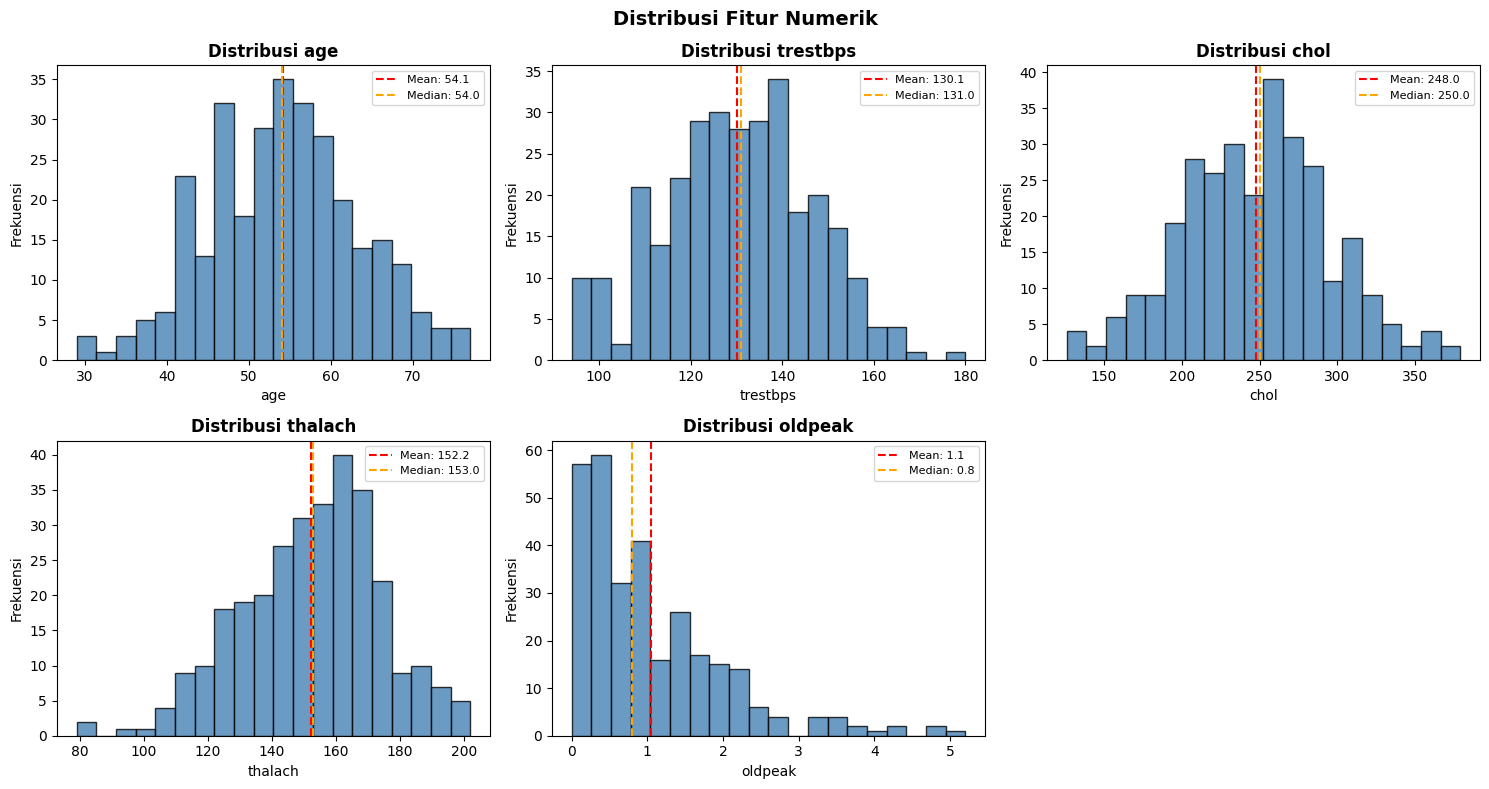

In [6]:
# --- 4.2 Distribusi Fitur Numerik ---
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

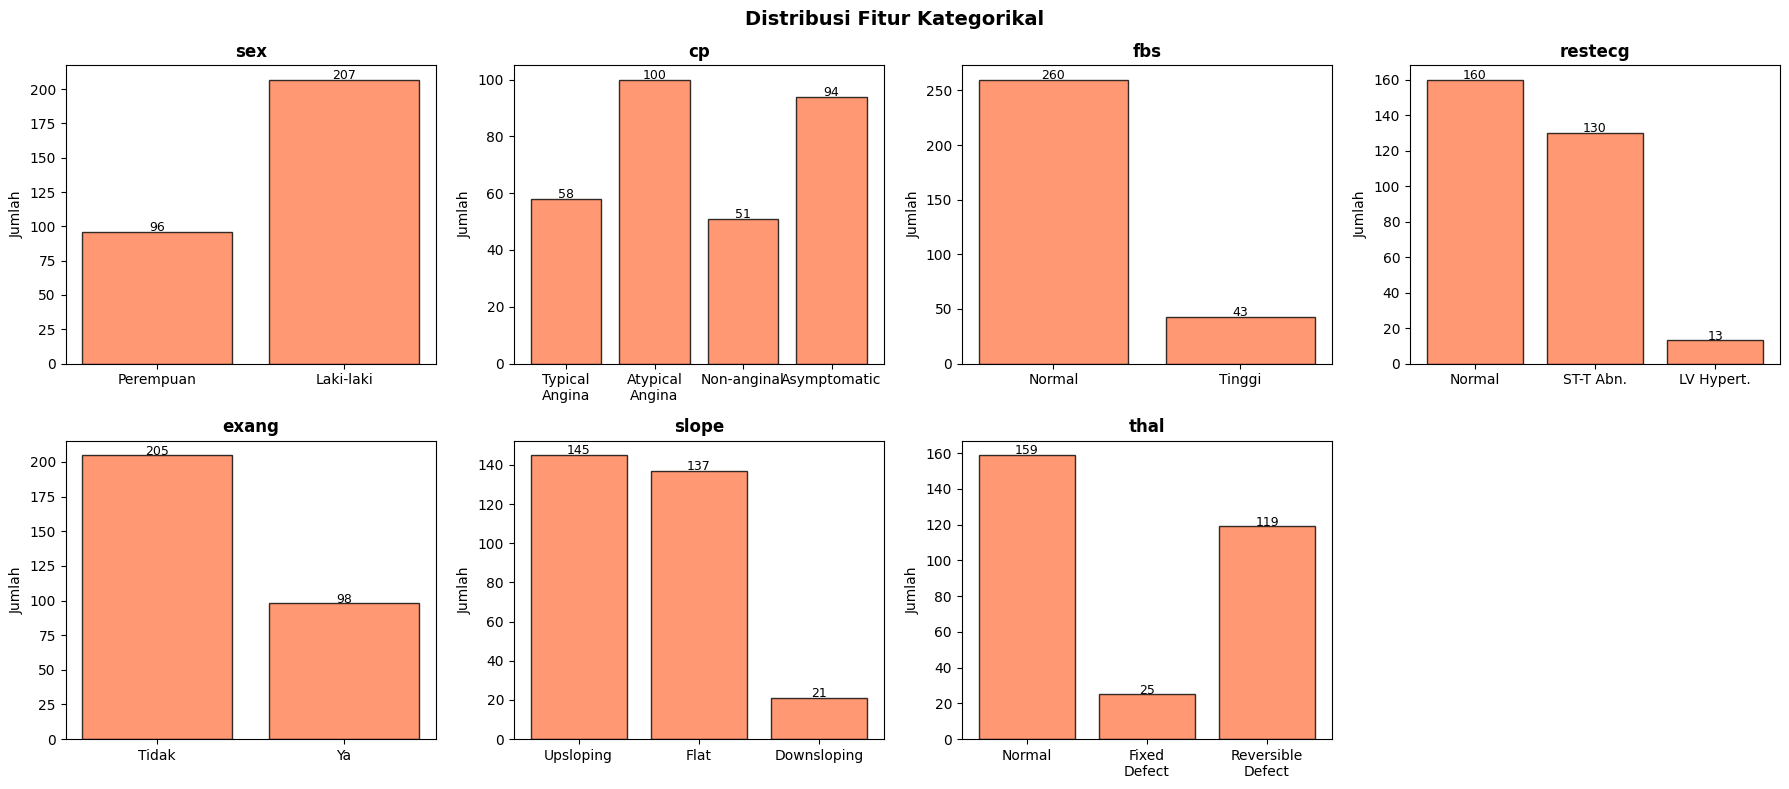

In [7]:
# --- 4.3 Distribusi Fitur Kategorikal ---
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
cat_labels = {
    'sex': {0: 'Perempuan', 1: 'Laki-laki'},
    'cp': {1: 'Typical\nAngina', 2: 'Atypical\nAngina', 3: 'Non-anginal', 4: 'Asymptomatic'},
    'fbs': {0: 'Normal', 1: 'Tinggi'},
    'restecg': {0: 'Normal', 1: 'ST-T Abn.', 2: 'LV Hypert.'},
    'exang': {0: 'Tidak', 1: 'Ya'},
    'slope': {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'thal': {3: 'Normal', 6: 'Fixed\nDefect', 7: 'Reversible\nDefect'}
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    counts = df[col].value_counts().sort_index()
    labels_col = [cat_labels[col].get(k, str(k)) for k in counts.index]
    axes[i].bar(labels_col, counts, color='coral', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    for j, v in enumerate(counts):
        axes[i].text(j, v + 0.3, str(v), ha='center', fontsize=9)

axes[7].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

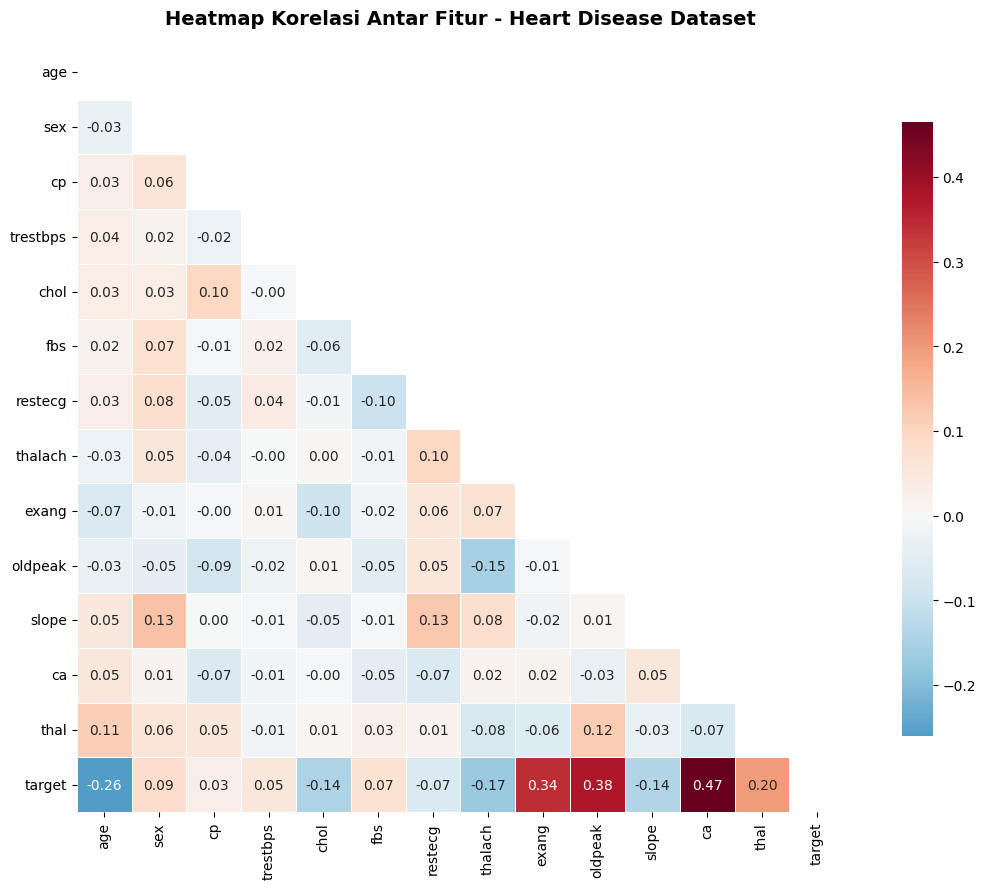

Korelasi fitur terhadap target (absolut):
ca          0.465404
oldpeak     0.376614
exang       0.341454
age         0.259684
thal        0.199143
thalach     0.174029
chol        0.141280
slope       0.138377
sex         0.088692
restecg     0.068266
fbs         0.067857
trestbps    0.052814
cp          0.031947


In [8]:
# --- 4.4 Heatmap Korelasi ---
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur - Heart Disease Dataset',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Fitur dengan korelasi tertinggi terhadap target
corr_target = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print('Korelasi fitur terhadap target (absolut):')
print(corr_target.to_string())

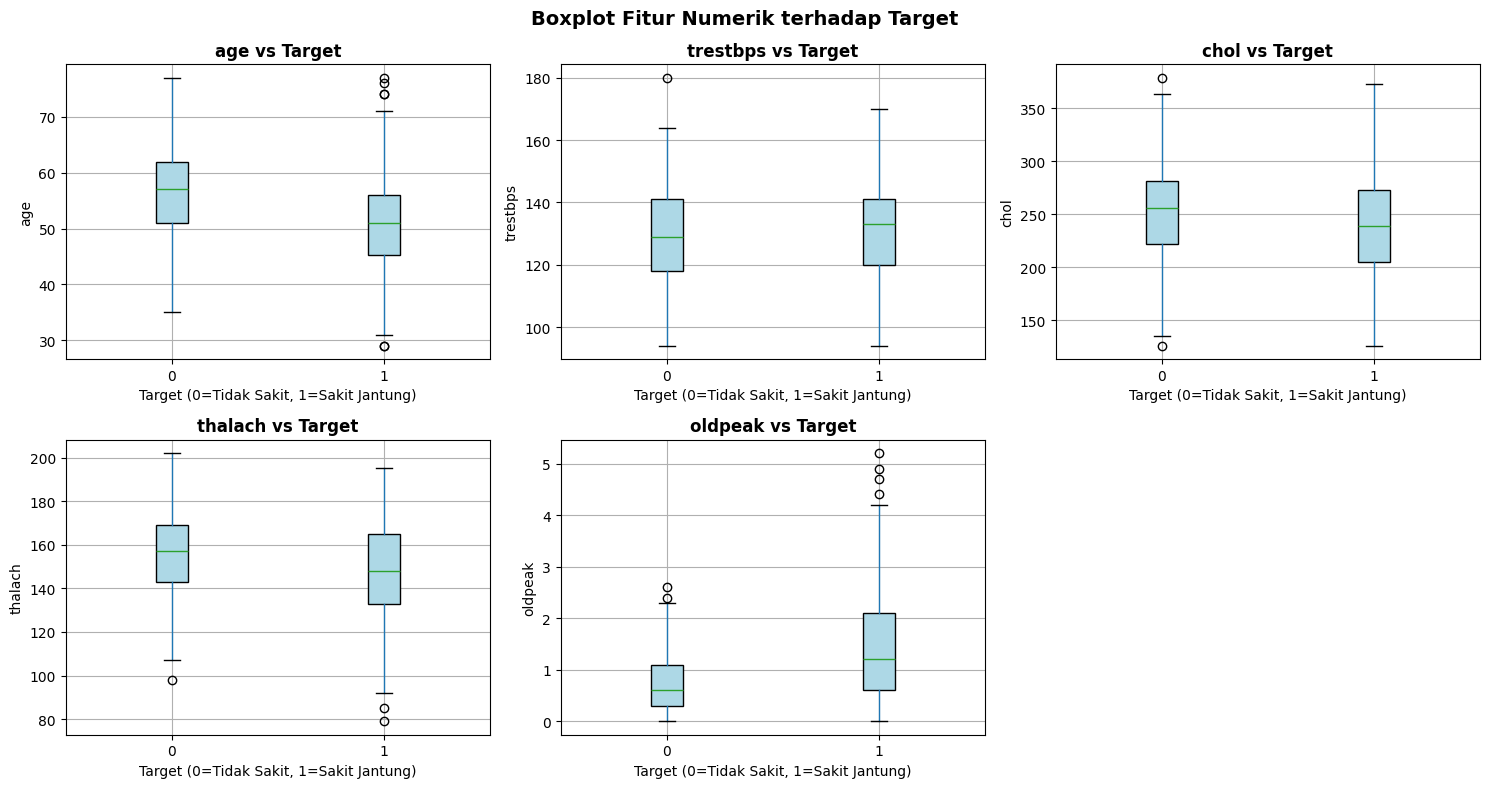

In [9]:
# --- 4.5 Boxplot Fitur Numerik vs Target ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    df.boxplot(
        column=col, by='target', ax=axes[i],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue')
    )
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel('Target (0=Tidak Sakit, 1=Sakit Jantung)')
    axes[i].set_ylabel(col)

axes[5].set_visible(False)
plt.suptitle('Boxplot Fitur Numerik terhadap Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# --- 4.6 Ringkasan Temuan EDA ---
print('=' * 60)
print('RINGKASAN TEMUAN EDA')
print('=' * 60)
print(f'Total sampel       : {len(df)}')
print(f'Kelas 0 (tidak sakit): {(df["target"]==0).sum()} ({(df["target"]==0).mean()*100:.1f}%)')
print(f'Kelas 1 (sakit)      : {(df["target"]==1).sum()} ({(df["target"]==1).mean()*100:.1f}%)')
print(f'\nFitur paling korelasi dengan target:')
print(corr_target.head(5).to_string())
print(f'\nMissing values : {df.isnull().sum().sum()}')
print(f'Duplikat       : {df.duplicated().sum()}')
print('=' * 60)

RINGKASAN TEMUAN EDA
Total sampel       : 303
Kelas 0 (tidak sakit): 173 (57.1%)
Kelas 1 (sakit)      : 130 (42.9%)

Fitur paling korelasi dengan target:
ca         0.465404
oldpeak    0.376614
exang      0.341454
age        0.259684
thal       0.199143

Missing values : 0
Duplikat       : 0


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing dilakukan untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Tahapan yang dilakukan:

1. Menangani Missing Values
2. Menghapus Data Duplikat
3. Feature Engineering (penambahan fitur bermakna klinis)
4. Normalisasi / Standarisasi Fitur
5. Train-Test Split
6. Menyimpan hasil preprocessing

In [11]:
# --- 5.1 Menangani Missing Values ---
print('Cek missing values sebelum preprocessing:')
print(df.isnull().sum())
print(f'Total missing values: {df.isnull().sum().sum()}')

# Imputasi median untuk fitur numerik (robust terhadap outlier)
TARGET_COL = 'target'
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_features_preprocess = [c for c in num_cols if c != TARGET_COL]

imputer = SimpleImputer(strategy='median')
df[num_features_preprocess] = imputer.fit_transform(df[num_features_preprocess])

print(f'\nMissing values setelah imputasi: {df.isnull().sum().sum()}')

Cek missing values sebelum preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Total missing values: 0

Missing values setelah imputasi: 0


In [12]:
# --- 5.2 Menghapus Data Duplikat ---
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f'Jumlah baris sebelum : {before}')
print(f'Duplikat dihapus     : {before - after}')
print(f'Jumlah baris sesudah : {after}')

Jumlah baris sebelum : 303
Duplikat dihapus     : 0
Jumlah baris sesudah : 303


In [13]:
# --- 5.3 Feature Engineering ---
# Menambahkan fitur turunan yang bermakna secara klinis

# Rasio denyut jantung maksimum terhadap usia
# (semakin rendah rasio ini, semakin menurun kapasitas kardiovaskular)
df['thalach_age_ratio'] = df['thalach'] / df['age']

# Indikator hipertensi: tekanan darah >= 140 mmHg
df['is_hypertensive'] = (df['trestbps'] >= 140).astype(int)

# Indikator kolesterol tinggi: kolesterol >= 240 mg/dl
df['is_high_chol'] = (df['chol'] >= 240).astype(int)

print(f'Shape setelah feature engineering: {df.shape}')
print('Fitur baru yang ditambahkan:')
print('  - thalach_age_ratio : rasio denyut jantung maks / usia')
print('  - is_hypertensive   : 1 jika trestbps >= 140')
print('  - is_high_chol      : 1 jika chol >= 240')
df[['thalach_age_ratio', 'is_hypertensive', 'is_high_chol']].head()

Shape setelah feature engineering: (303, 17)
Fitur baru yang ditambahkan:
  - thalach_age_ratio : rasio denyut jantung maks / usia
  - is_hypertensive   : 1 jika trestbps >= 140
  - is_high_chol      : 1 jika chol >= 240


,thalach_age_ratio,is_hypertensive,is_high_chol
0,2.444444,1,0
1,2.698413,0,1
2,2.228070,1,1
3,3.707317,0,0
4,2.224490,0,1


In [14]:
# --- 5.4 Train-Test Split ---
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Menjaga proporsi kelas di train dan test
)

print(f'Total sampel    : {len(df)}')
print(f'Train set       : {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Test  set       : {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'Jumlah fitur    : {X_train.shape[1]}')
print(f'\nDistribusi y_train :\n{y_train.value_counts().to_string()}')
print(f'\nDistribusi y_test  :\n{y_test.value_counts().to_string()}')

Total sampel    : 303
Train set       : 242 sampel (80%)
Test  set       : 61 sampel (20%)
Jumlah fitur    : 16

Distribusi y_train :
target
0    138
1    104

Distribusi y_test  :
target
0    35
1    26


In [15]:
# --- 5.5 Standarisasi Fitur ---
# StandardScaler: mean=0, std=1 — cocok untuk GradientBoosting
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print('Standarisasi selesai.')
print(f'Mean fitur X_train (setelah scaling, sampel pertama):')
print(X_train_scaled.mean().round(4).to_string())

Standarisasi selesai.
Mean fitur X_train (setelah scaling, sampel pertama):
age                  0.0
sex                  0.0
cp                  -0.0
trestbps            -0.0
chol                 0.0
fbs                 -0.0
restecg             -0.0
thalach             -0.0
exang                0.0
oldpeak             -0.0
slope                0.0
ca                  -0.0
thal                -0.0
thalach_age_ratio    0.0
is_hypertensive      0.0
is_high_chol         0.0


In [16]:
# --- 5.6 Menyimpan Hasil Preprocessing ---
OUTPUT_DIR = 'heart_disease_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_scaled.to_csv(f'{OUTPUT_DIR}/X_train.csv', index=False)
X_test_scaled.to_csv(f'{OUTPUT_DIR}/X_test.csv', index=False)
y_train.reset_index(drop=True).to_csv(f'{OUTPUT_DIR}/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv(f'{OUTPUT_DIR}/y_test.csv', index=False)

scaler_payload = {'scaler': scaler, 'feature_names': list(X_train.columns)}
with open(f'{OUTPUT_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_payload, f)

print(f'File disimpan di folder "{OUTPUT_DIR}/":')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size = os.path.getsize(fpath)
    print(f'  {fname:30s} ({size:,} bytes)')

File disimpan di folder "heart_disease_preprocessing/":
  .ipynb_checkpoints             (0 bytes)
  X_test.csv                     (19,258 bytes)
  X_train.csv                    (76,091 bytes)
  scaler.pkl                     (1,104 bytes)
  y_test.csv                     (191 bytes)
  y_train.csv                    (734 bytes)


In [17]:
# --- 5.7 Verifikasi Akhir ---
X_train_check = pd.read_csv(f'{OUTPUT_DIR}/X_train.csv')
X_test_check  = pd.read_csv(f'{OUTPUT_DIR}/X_test.csv')
y_train_check = pd.read_csv(f'{OUTPUT_DIR}/y_train.csv')
y_test_check  = pd.read_csv(f'{OUTPUT_DIR}/y_test.csv')

print('=' * 55)
print('VERIFIKASI DATA HASIL PREPROCESSING')
print('=' * 55)
print(f'X_train : {X_train_check.shape}')
print(f'X_test  : {X_test_check.shape}')
print(f'y_train : {y_train_check.shape}')
print(f'y_test  : {y_test_check.shape}')
print(f'\nMissing values X_train : {X_train_check.isnull().sum().sum()}')
print(f'Missing values X_test  : {X_test_check.isnull().sum().sum()}')
print(f'\nSemua nilai sudah dalam skala standar:')
print(f'  X_train mean ≈ {X_train_check.mean().mean():.4f} (harusnya mendekati 0)')
print(f'  X_train std  ≈ {X_train_check.std().mean():.4f}  (harusnya mendekati 1)')
print('=' * 55)
print('Preprocessing selesai! Data siap untuk pelatihan model.')

X_train_check.head()

VERIFIKASI DATA HASIL PREPROCESSING
X_train : (242, 16)
X_test  : (61, 16)
y_train : (242, 1)
y_test  : (61, 1)

Missing values X_train : 0
Missing values X_test  : 0

Semua nilai sudah dalam skala standar:
  X_train mean ≈ 0.0000 (harusnya mendekati 0)
  X_train std  ≈ 1.0021  (harusnya mendekati 1)
Preprocessing selesai! Data siap untuk pelatihan model.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,thalach_age_ratio,is_hypertensive,is_high_chol
0,-0.961306,0.68313,0.424299,-0.369524,-0.288796,-0.39036,0.797324,0.315764,1.450022,-0.584132,-0.978918,-0.760324,-0.973738,0.843669,-0.605996,-1.104619
1,0.964844,-1.46385,-1.377112,-1.939483,-0.864011,-0.39036,-0.940986,-1.237959,-0.689645,0.902750,0.643672,2.486707,1.102426,-1.265417,-0.605996,-1.104619
2,0.322794,-1.46385,-0.476406,-1.123104,-1.521400,-0.39036,0.797324,0.362847,1.450022,-0.584132,-0.978918,1.404363,-0.973738,-0.157660,-0.605996,-1.104619
3,-0.105240,0.68313,1.325005,-0.495121,0.368593,-0.39036,0.797324,-0.155061,-0.689645,-0.265515,-0.978918,0.322020,1.102426,-0.149952,-0.605996,0.905289
4,-1.496348,0.68313,-1.377112,0.321258,-0.268253,-0.39036,0.797324,0.362847,-0.689645,-0.265515,0.643672,-0.760324,-0.973738,1.486723,-0.605996,-1.104619
